<h1> Abgabe 1 </h1>
<h2> Mathematische Hintergründe maschinellen Lernens (Mathe3)</h2>
<h2> Fabian Schmitz | s0585197 </h2>

<h2> Hinweise zur Abgabe </h2>
<p>Aufgaben mit handschriftlicher Abgabe sind im PDF markiert. Die Python-Teile sind hier vorbereitet.</p>

<h2> Aufgabe 1: Spektrale Zerlegung </h2>
<p>Matrix:</p>
$$A = \begin{pmatrix}6 & 2 & 0\\ 2 & 3 & 0\\ 0 & 0 & 4\end{pmatrix}$$
<p>a) Eigenwerte berechnen.</p>
<p>b) Normierte Eigenvektoren und spektrale Zerlegung $A = \Gamma\Lambda\Gamma^\top$.</p>
<p>c) Numerische Verifikation in Python.</p>

In [4]:
import numpy as np

# Matrix A aus Aufgabe 1
A = np.array([[6, 2, 0], [2, 3, 0], [0, 0, 4]], dtype=float)

# eigh ist fuer symmetrische Matrizen passend
eigvals, eigvecs = np.linalg.eigh(A)

# Spur (trace) und Determinante
trace = np.trace(A)
det = np.linalg.det(A)

print("Eigenwerte:", eigvals)
print("trace(A):", trace, " | Summe Eigenwerte:", eigvals.sum())
print("det(A):", det, " | Produkt Eigenwerte:", eigvals.prod())

# kleine Checks (sollten True sein)
print("Trace-Check:", np.isclose(trace, eigvals.sum()))
print("Det-Check:", np.isclose(det, eigvals.prod()))

Eigenwerte: [2. 4. 7.]
trace(A): 13.0  | Summe Eigenwerte: 13.0
det(A): 56.00000000000002  | Produkt Eigenwerte: 55.99999999999999
Trace-Check: True
Det-Check: True


<h2> Aufgabe 2: Winkel und Skalarprodukte </h2>
<p>Vektoren $u = (1, 3)^\top$, $v = (4, -2)^\top$, Matrix</p>
$$C = \begin{pmatrix}4 & 1\\ 1 & 3\end{pmatrix}$$
<p>a) Winkel mit Standardskalarprodukt.</p>
<p>b) Winkel mit $\langle u, v \rangle_C = u^\top C v$.</p>
<p>c) Vergleich der Winkel.</p>
<p>d) Numerische Verifikation in Python.</p>

In [5]:
import numpy as np

# Eingabevektoren und Matrix C
u = np.array([1, 3], dtype=float)
v = np.array([4, -2], dtype=float)
C = np.array([[4, 1], [1, 3]], dtype=float)

def angle_standard(a, b):
    # in Python ist @ die Matrix-/Vektor-Multiplikation
    cos_val = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
    # numerische Sicherheit: cos muss in [-1, 1] liegen
    cos_val = np.clip(cos_val, -1.0, 1.0)
    return np.arccos(cos_val)

def angle_weighted(a, b, M):
    # gewichtetes Skalarprodukt: a^T * M * b
    inner = a.T @ M @ b
    norm_a = np.sqrt(a.T @ M @ a)
    norm_b = np.sqrt(b.T @ M @ b)
    cos_val = inner / (norm_a * norm_b)
    cos_val = np.clip(cos_val, -1.0, 1.0)
    return np.arccos(cos_val)

theta_std = angle_standard(u, v)
theta_C = angle_weighted(u, v, C)

print("Winkel (Standard):", theta_std, "rad |", np.degrees(theta_std), "deg")
print("Winkel (C-gewichtet):", theta_C, "rad |", np.degrees(theta_C), "deg")

Winkel (Standard): 1.7126933813990606 rad | 98.13010235415598 deg
Winkel (C-gewichtet): 1.4001792036422058 rad | 80.22435893068702 deg


<h2> Aufgabe 4: Lineare Regression mit Diabetes-Daten </h2>
<p>Verwenden Sie <code>load_diabetes</code> aus <code>sklearn.datasets</code>.</p>
<p>a) Datensatz kurz beschreiben.</p>
<p>b) Train/Test-Split (80/20, random_state=42).</p>
<p>c) Standardisierung der Merkmale (nur X, nur Trainingsdaten fitten).</p>
<p>d) Lineare Regression per Normalengleichung oder <code>numpy.linalg.lstsq</code>.</p>
<p>e) Streudiagramm: wahre vs. vorhergesagte Werte, Diagonale y=x.</p>
<p>f) Ein Merkmal (z.B. bmi) und einfache Regression, Vergleich der Guete.</p>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Datensatz laden
data = load_diabetes()
X = data.data
y = data.target

# kleine Beschreibung ausgeben
print("Beobachtungen, Merkmale:", X.shape)
print("feature_names:", data.feature_names)
print("Zielvariable:", "Quantitativer Verlauf ein Jahr nach der Baseline-Messung von Diabetispatient*innen")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler nur mit Trainingsdaten bilden
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Beobachtungen, Merkmale: (442, 10)
feature_names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Zielvariable: Quantitativer Verlauf ein Jahr nach der Baseline-Messung


MSE (multivariat): 2900.193628493482
R2 (multivariat): 0.45260276297191937


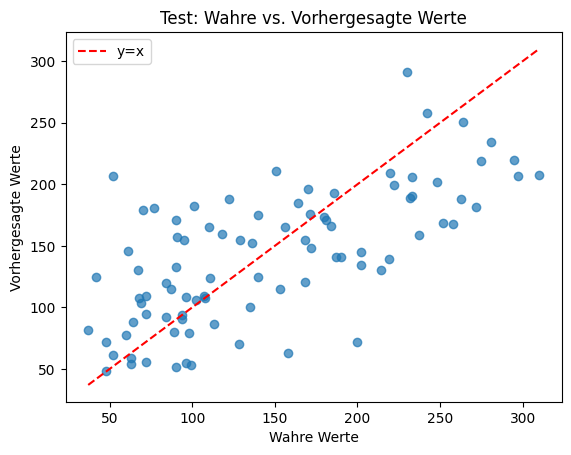

In [7]:
# Multivariate Regression per Normalengleichung
# np.c_ haengt eine 1er-Spalte an (Bias-Term)
X_train_aug = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_aug = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# Loesung mit kleinster Quadrate (lstsq)
beta_hat = np.linalg.lstsq(X_train_aug, y_train, rcond=None)[0]
y_pred = X_test_aug @ beta_hat

# einfache Metriken
mse_multi = mean_squared_error(y_test, y_pred)
r2_multi = r2_score(y_test, y_pred)
print("MSE (multivariat):", mse_multi)
print("R2 (multivariat):", r2_multi)

# Plot: wahre vs. vorhergesagte Werte
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
plt.xlabel("Wahre Werte")
plt.ylabel("Vorhergesagte Werte")
plt.title("Test: Wahre vs. Vorhergesagte Werte")
plt.legend()
plt.show()

MSE (ein Merkmal): 4061.8259284949268
R2 (ein Merkmal): 0.23335039815872138


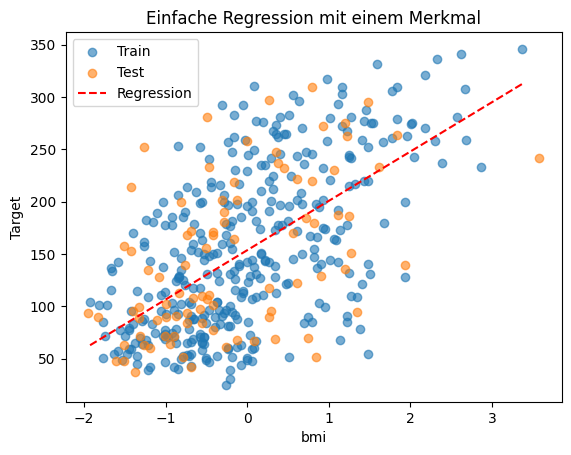

In [8]:
# Einfache Regression mit einem Merkmal (z.B. bmi)
feature = "bmi"
feature_idx = data.feature_names.index(feature)

# nur eine Spalte aus X holen
X_single = X[:, [feature_idx]]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

# wieder standardisieren (nur Trainingsdaten fitten)
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

# Bias-Term ergaenzen
X_train_s_aug = np.c_[np.ones(X_train_s_scaled.shape[0]), X_train_s_scaled]
X_test_s_aug = np.c_[np.ones(X_test_s_scaled.shape[0]), X_test_s_scaled]

beta_hat_s = np.linalg.lstsq(X_train_s_aug, y_train_s, rcond=None)[0]
y_pred_s = X_test_s_aug @ beta_hat_s

mse_single = mean_squared_error(y_test_s, y_pred_s)
r2_single = r2_score(y_test_s, y_pred_s)
print("MSE (ein Merkmal):", mse_single)
print("R2 (ein Merkmal):", r2_single)

# Regressionsgerade fuer das Plotten
x_line = np.linspace(X_train_s_scaled.min(), X_train_s_scaled.max(), 200).reshape(-1, 1)
x_line_aug = np.c_[np.ones(x_line.shape[0]), x_line]
y_line = x_line_aug @ beta_hat_s

plt.figure()
plt.scatter(X_train_s_scaled, y_train_s, alpha=0.6, label="Train")
plt.scatter(X_test_s_scaled, y_test_s, alpha=0.6, label="Test")
plt.plot(x_line, y_line, "r--", label="Regression")
plt.xlabel(feature)
plt.ylabel("Target")
plt.title("Einfache Regression mit einem Merkmal")
plt.legend()
plt.show()